In [144]:
# Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
# Load the Fear & Greed sentiment dataset and the historical trading dataset
sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

In [145]:
# Preview the first few rows of the sentiment dataset
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [77]:
# Preview the first few rows of the trading dataset
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [78]:
# Checking the dimensions
sentiment.shape

(2644, 4)

In [80]:
# Checking the dimensions
trades.shape

(211224, 16)

In [81]:
# Counting the number of missing (null) values in each column
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [82]:
# Counting the number of missing (null) values in each column
trades.isnull().sum(),

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [13]:
#show the column names
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [12]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date

In [84]:
#show the column names
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [147]:
# Converting the 'Timestamp IST' column to datetime format
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
# Creating a new 'date' column by extracting only the date from the timestamp
trades['date'] = trades['Timestamp IST'].dt.date

In [86]:
# Removing rows where the 'Timestamp IST' column has missing
trades = trades.dropna(subset=['Timestamp IST'])

In [148]:
# Displaying the first 5 rows of the 'Timestamp IST' and 'date' columns to verify the conversion
trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-02-12 22:50:00,2024-02-12
1,2024-02-12 22:50:00,2024-02-12
2,2024-02-12 22:50:00,2024-02-12
3,2024-02-12 22:50:00,2024-02-12
4,2024-02-12 22:50:00,2024-02-12


In [88]:
# Displaying the first 5 rows of the 'timestamp' and 'date' columns
sentiment[['timestamp','date']].head()

,timestamp,date
0,1517463000,2018-02-01
1,1517549400,2018-02-02
2,1517635800,2018-02-03
3,1517722200,2018-02-04
4,1517808600,2018-02-05


In [105]:
# Merging the trades dataset with the sentiment dataset using the common 'date' column
merged = pd.merge(
    trades,
    sentiment[['date','classification']],
    on='date',
    how='inner'
)

In [106]:
# Displaying the first 5 rows of the merged dataset
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


In [149]:
# Displaying the first 5 rows of the selected columns to view date, sentiment classification, and trade profit/loss
merged[['date','classification','Closed PnL']].head()

,date,classification,Closed PnL
0,2024-02-12,Greed,0.0
1,2024-02-12,Greed,0.0
2,2024-02-12,Greed,0.0
3,2024-02-12,Greed,0.0
4,2024-02-12,Greed,0.0


In [108]:
# Counting how many times each sentiment classification
merged['classification'].value_counts()

,count
classification,
Fear,13869
Greed,11292
Extreme Greed,5621
Neutral,2756
Extreme Fear,2326


In [116]:
# Creating a new column 'win' that marks True if the trade made a profit (Closed PnL > 0) and False otherwise
merged['win'] = merged['Closed PnL'] > 0

In [127]:
# Creating a new column 'trader_type' based on the 'win' column
# If win is True → label as 'Winner', otherwise label as 'Loser'
merged['trader_type'] = merged['win'].apply(lambda x: 'Winner' if x else 'Loser')

merged.groupby('trader_type')['Closed PnL'].mean()

,Closed PnL
trader_type,
Loser,-35.37297
Winner,283.00209


In [128]:
# Calculating the average Closed PnL for each sentiment classification
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,1.891632
Extreme Greed,205.816345
Fear,128.287950
Greed,53.988003
Neutral,27.088803


In [129]:
# Converting the 'Closed PnL' column to numeric values
merged['Closed PnL'] = pd.to_numeric(merged['Closed PnL'], errors='coerce')

In [130]:
# Displaying summary statistics
merged['Closed PnL'].describe()

,Closed PnL
count,35864.000000
mean,101.070948
std,1364.610762
min,-117990.104100
25%,0.000000
50%,0.000000
75%,10.735428
max,71535.716740


In [150]:
# Removing rows where the 'classification' (sentiment label) is missing
merged = merged.dropna(subset=['classification'])

In [151]:
# Counting the number of occurrences of each sentiment classification in the merged dataset
merged['classification'].value_counts()

,count
classification,
Fear,13869
Greed,11292
Extreme Greed,5621
Neutral,2756
Extreme Fear,2326


In [133]:
# Displaying summary statistics of the 'Closed PnL' column
merged['Closed PnL'].describe()

,Closed PnL
count,35864.000000
mean,101.070948
std,1364.610762
min,-117990.104100
25%,0.000000
50%,0.000000
75%,10.735428
max,71535.716740


In [134]:
# Removing rows where the 'classification' column has missing (NaN) values
merged = merged.dropna(subset=['classification'])

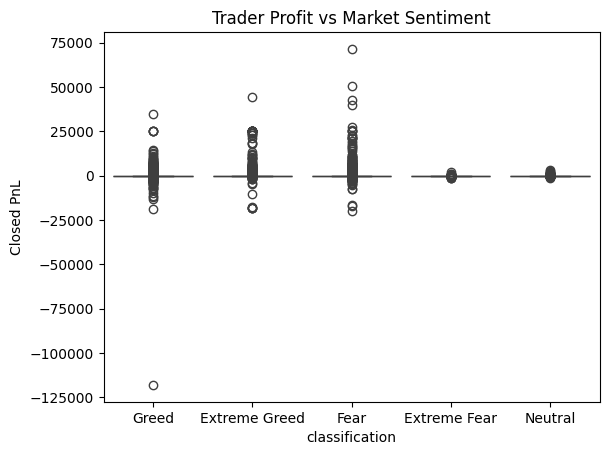

In [135]:
# Creating a box plot to visualize the distribution of Closed PnL across different sentiment classifications
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=merged, x='classification', y='Closed PnL')
plt.title("Trader Profit vs Market Sentiment")
plt.show()

In [136]:
# Calculating the average trade size (in USD) for each sentiment classification
merged.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,4118.761840
Extreme Greed,3242.085086
Fear,5744.782685
Greed,5051.878829
Neutral,4332.202906


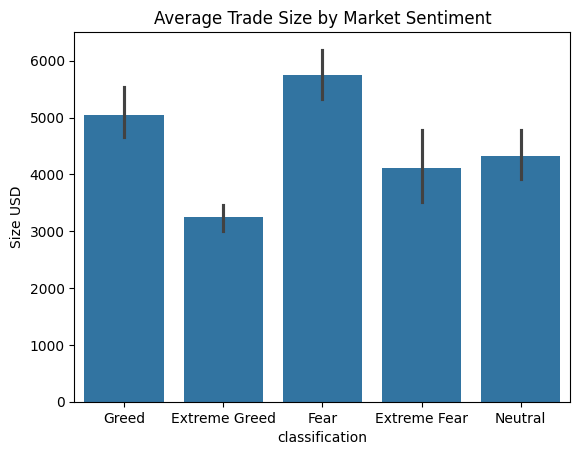

In [137]:
# Creating a bar plot to visualize the average trade size (Size USD) for each sentiment classification
sns.barplot(data=merged, x='classification', y='Size USD')
plt.title("Average Trade Size by Market Sentiment")
plt.show()

Insight 1
Trader profits vary significantly across market sentiment categories, with larger profit and loss ranges observed during Greed and Fear market conditions.

Insight 2
The average trade size tends to increase during Fear and Greed market sentiment, suggesting traders adjust their position sizes based on perceived market opportunities.

Insight 3
Extreme sentiment conditions show higher variability in trading outcomes, indicating increased market volatility during these periods.

Strategy 1
During Extreme Fear periods, traders should consider reducing trade sizes to limit potential downside risk.

Strategy 2
During Greed periods, traders may increase participation but should implement risk management strategies such as stop-loss limits.

Bonus task

In [138]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [139]:
features = merged[['Closed PnL', 'Size USD']]

In [140]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [141]:
kmeans = KMeans(n_clusters=3, random_state=42)
merged['cluster'] = kmeans.fit_predict(scaled_features)

In [142]:
merged.groupby('cluster')[['Closed PnL', 'Size USD']].mean()

,Closed PnL,Size USD
cluster,,
0,95.563684,4311.273678
1,6283.763476,416743.160392
2,-117990.104100,814524.170000


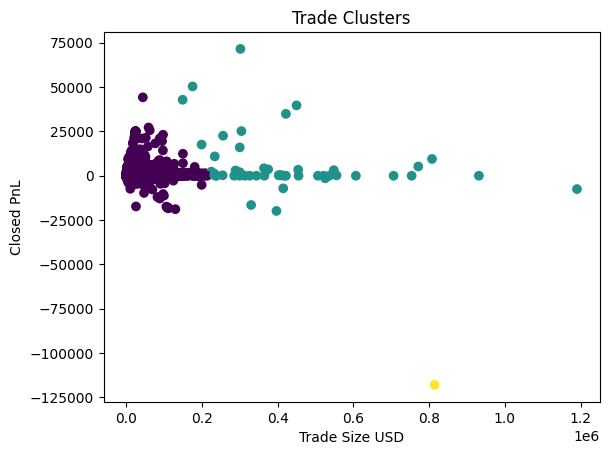

In [143]:
import matplotlib.pyplot as plt

plt.scatter(merged['Size USD'], merged['Closed PnL'], c=merged['cluster'])
plt.xlabel("Trade Size USD")
plt.ylabel("Closed PnL")
plt.title("Trade Clusters")
plt.show()

Clustering reveals distinct trading behaviors, where some clusters represent high-risk large trades with large profit/loss ranges, while others consist of smaller trades with lower volatility.